# Bethe ansatz and ED check for the periodic XXZ chain

This notebook compares the Bethe-ansatz ground-state energy with exact diagonalization for

$$
H = \sum_{i=1}^{L} \left(S_i^x S_{i+1}^x + S_i^y S_{i+1}^y + \Delta S_i^z S_{i+1}^z\right) + h \sum_{i=1}^{L} S_i^z
$$

using the rapidity convention

$$
u_j = -\frac{\eta}{2} + \frac{i\alpha_j}{2}, \qquad \Delta = \cos\eta.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh

from quante.generate.solvable.bethe_ansatz import solve_xxz_state, xxz_energy, xxz_energy_density
from quante.generate.solvable.heisenberg import xxz_matrix
import quante as qt

Delta = 0.7

## Ground State Energy

In [2]:
eng1 = qt.generate.solvable.heisenberg.xxz_pbc_finite_ground_energy(
    L=16, j=1., delta=0.7, pauli=True
)
oper = qt.generate.heisenberg_operator(L=16, j=(1,1,0.7), hz=0, cyclic=True)
basis = qt.generate.basis.spin_basis(L=16, Nup=8)
mat = oper.to_matrix(basis=basis, pauli=True, sparse=True)
eng = eigsh(mat, k=1, which='SA')[0][0]
print("ED energy:", eng)
print("BA energy:", eng1)

ED energy: -25.843739220314916
BA energy: -25.843739220314948


In [3]:
eng1 = qt.generate.solvable.heisenberg.xxz_pbc_finite_ground_energy(
    L=16, j=-1., delta=0.7, pauli=True
)
oper = qt.generate.heisenberg_operator(L=16, j=(-1,-1,-0.7), hz=0, cyclic=True)
basis = qt.generate.basis.spin_basis(L=16, Nup=8)
mat = oper.to_matrix(basis=basis, pauli=True, sparse=True)
eng = eigsh(mat, k=1, which='SA')[0][0]
print("ED energy:", eng)
print("BA energy:", eng1)

ED energy: -16.800983831035925
BA energy: -16.800983831035907


In [4]:
eng1 = qt.generate.solvable.heisenberg.xxz_pbc_finite_ground_energy(
    L=16, j=1., delta=0.7, h=2, pauli=True
)
oper = qt.generate.heisenberg_operator(L=16, j=(1,1,0.7), hz=2, cyclic=True)
basis = qt.generate.basis.spin_basis(L=16)
mat = oper.to_matrix(basis=basis, pauli=True, sparse=True)
eng = eigsh(mat, k=1, which='SA')[0][0]
print("ED energy:", eng)
print("BA energy:", eng1)

ED energy: -30.95146905318618
BA energy: -30.95146905318615


In [5]:
eng1 = qt.generate.solvable.heisenberg.xxz_pbc_finite_ground_energy(
    L=16, j=-1., delta=0.7, h=2, pauli=True
)
oper = qt.generate.heisenberg_operator(L=16, j=(-1,-1,-0.7), hz=2, cyclic=True)
basis = qt.generate.basis.spin_basis(L=16)
mat = oper.to_matrix(basis=basis, pauli=True, sparse=True)
eng = eigsh(mat, k=1, which='SA')[0][0]
print("ED energy:", eng)
print("BA energy:", eng1)

ED energy: -43.20000000000002
BA energy: -43.2


infinite size limit

In [6]:
L = 1000
eng1 = qt.generate.solvable.heisenberg.xxz_pbc_finite_ground_energy(
    L=L, j=1., delta=0.7, pauli=True
)
eng2 = qt.generate.solvable.heisenberg.xxz_pbc_infinite_ground_energy(
    j=1., delta=0.7, pauli=True
)
print(f"finite energy   : {eng1/L:.10f}")
print(f"infinite energy : {eng2:.10f}")

finite energy   : -1.6036119114
infinite energy : -1.6036089576


In [7]:
L = 1000
eng1 = qt.generate.solvable.heisenberg.xxz_pbc_finite_ground_energy(
    L=L, j=-1., delta=0.7, pauli=True
)
eng2 = qt.generate.solvable.heisenberg.xxz_pbc_infinite_ground_energy(
    j=-1., delta=0.7, pauli=True
)
print(f"finite energy   : {eng1/L:.10f}")
print(f"infinite energy : {eng2:.10f}")

finite energy   : -1.0461538948
infinite energy : -1.0461528934


In [8]:
L = 1000
eng1 = qt.generate.solvable.heisenberg.xxz_pbc_finite_ground_energy(
    L=L, j=1., delta=0.7, h=2, pauli=True
)
eng2 = qt.generate.solvable.heisenberg.xxz_pbc_infinite_ground_energy(
    j=1., delta=0.7, h=2, pauli=True
)
print(f"finite energy   : {eng1/L:.10f}")
print(f"infinite energy : {eng2:.10f}")

finite energy   : -1.9277869774
infinite energy : -1.9277853053


In [9]:
L = 1000
eng1 = qt.generate.solvable.heisenberg.xxz_pbc_finite_ground_energy(
    L=L, j=-1., delta=0.7, h=2, pauli=True
)
eng2 = qt.generate.solvable.heisenberg.xxz_pbc_infinite_ground_energy(
    j=-1., delta=0.7, h=2, pauli=True
)
print(f"finite energy   : {eng1/L:.10f}")
print(f"infinite energy : {eng2:.10f}")

epsilon_B(0+) > 0: the sea is empty. Returning B = 0.
epsilon_B(0+) > 0: the sea is empty. Returning B = 0.
finite energy   : -2.7000000000
infinite energy : -2.7000000000


## Ground-state roots


Bethe State Information

In [10]:
L = 16

state = solve_xxz_state(L, Delta, M=L // 2)
E_ba = xxz_energy(state)

print(f"converged      : {state.converged}")
print(f"residual norm  : {state.residual_norm:.3e}")
print(f"Bethe numbers  : {state.qnums}")
print(f"BA energy      : {E_ba:.15f}")
print(f"BA energy / L  : {xxz_energy_density(state):.15f}")

converged      : True
residual norm  : 7.640e-15
Bethe numbers  : [-3.5 -2.5 -1.5 -0.5  0.5  1.5  2.5  3.5]
BA energy      : -25.843739220314948
BA energy / L  : -1.615233701269684


The roots below are shown in the complex $u$ plane.

(-1.0, 0.2)

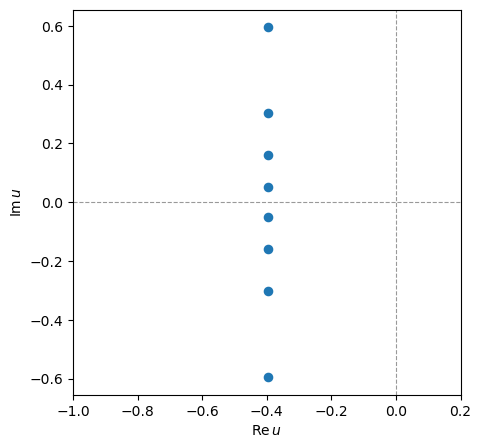

In [11]:
u = state.roots
ax = state.plot_roots()
ax.set_xlim([-1,0.2])

## Single-particle momenta

For the same convention used by the solver,

$$
p(\alpha) = \theta_1(\alpha/2)
          = 2\arctan\left[\frac{\tanh(\alpha/2)}{\tan(\eta/2)}\right].
$$

The total momentum is computed modulo $2\pi$.

In [12]:
eta = state.eta
alpha = state.alphas

p = 2.0 * np.arctan(np.tanh(alpha / 2.0) / np.tan(eta / 2.0))
p = (p + np.pi) % (2.0 * np.pi) - np.pi
P_total = (np.sum(p) + np.pi) % (2.0 * np.pi) - np.pi

print("alpha:")
print(alpha)
print("\np:")
print(p)
print(f"\ntotal momentum modulo 2pi: {P_total:.15e}")

alpha:
[-1.19109655 -0.60696555 -0.31818188 -0.10033172  0.10033172  0.31818188  0.60696555  1.19109655]

p:
[-1.8082388  -1.22285003 -0.71850406 -0.2375142   0.2375142   0.71850406  1.22285003  1.8082388 ]

total momentum modulo 2pi: 0.000000000000000e+00


## Try your own Bethe quantum numbers

Edit `qnums_custom` to inspect another state on the same real-root branch. Some choices may require a better initial guess or a different root branch; in that case `converged` and `residual_norm` are useful diagnostics.

In [13]:
qnums_custom = np.array([-7/2,-5/2,-3/2,-1/2,1/2,5/2,7/2])

custom_state = solve_xxz_state(
    L,
    Delta,
    qnums=qnums_custom,
    raise_error=False,
)

custom_p = 2.0 * np.arctan(
    np.tanh(custom_state.alphas / 2.0) / np.tan(custom_state.eta / 2.0)
)
custom_p = (custom_p + np.pi) % (2.0 * np.pi) - np.pi
custom_P_total = (np.sum(custom_p) + np.pi) % (2.0 * np.pi) - np.pi

print(f"converged      : {custom_state.converged}")
print(f"residual norm  : {custom_state.residual_norm:.3e}")
print(f"qnums          : {custom_state.qnums}")
print(f"alpha          : {custom_state.alphas}")
print(f"p              : {custom_p}")
print(f"total momentum : {custom_P_total:.15e}")
print(f"energy         : {xxz_energy(custom_state):.15f}")
print(f"energy / L     : {xxz_energy_density(custom_state):.15f}")

converged      : True
residual norm  : 2.850e-14
qnums          : [-3.5 -2.5 -1.5 -0.5  0.5  2.5  3.5]
alpha          : [-1.05705257 -0.57114516 -0.30062491 -0.09038085  0.10524635  0.59233981  1.09199668]
p              : [-1.71247429 -1.16939442 -0.68250111 -0.21418057  0.24901071  1.20132486  1.73916619]
total momentum : -5.890486225480838e-01
energy         : -21.061428232059324
energy / L     : -1.316339264503708


(-1.0, 0.2)

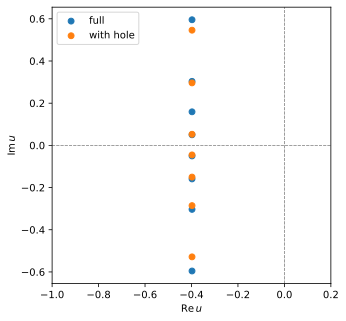

In [14]:
qt.basicfun.plt_style_use('default')
u = custom_state.roots
ax = state.plot_roots(label='full')
ax = custom_state.plot_roots(ax=ax, label="with hole")
ax.legend()
ax.set_xlim([-1,0.2])

## Large L

In [3]:
L = 1000
Delta = 0.7

largeL_state = solve_xxz_state(L, Delta, M=L // 2)
E_ba = xxz_energy(largeL_state)

print(f"converged      : {largeL_state.converged}")
print(f"residual norm  : {largeL_state.residual_norm:.3e}")
print(f"Bethe numbers  : {largeL_state.qnums}")
print(f"BA energy      : {E_ba:.15f}")
print(f"BA energy / L  : {xxz_energy_density(largeL_state):.15f}")

converged      : True
residual norm  : 1.586e-12
Bethe numbers  : [-249.5 -248.5 -247.5 -246.5 -245.5 -244.5 -243.5 -242.5 -241.5 -240.5 -239.5 -238.5 -237.5 -236.5 -235.5 -234.5 -233.5 -232.5 -231.5 -230.5 -229.5 -228.5 -227.5 -226.5 -225.5 -224.5 -223.5 -222.5 -221.5 -220.5 -219.5 -218.5 -217.5 -216.5 -215.5 -214.5 -213.5 -212.5 -211.5 -210.5 -209.5 -208.5 -207.5 -206.5 -205.5 -204.5 -203.5 -202.5 -201.5 -200.5 -199.5 -198.5 -197.5 -196.5 -195.5 -194.5 -193.5 -192.5 -191.5 -190.5 -189.5 -188.5 -187.5 -186.5 -185.5 -184.5 -183.5 -182.5 -181.5 -180.5 -179.5 -178.5 -177.5 -176.5 -175.5 -174.5 -173.5 -172.5 -171.5 -170.5 -169.5 -168.5 -167.5 -166.5 -165.5 -164.5 -163.5 -162.5 -161.5 -160.5 -159.5 -158.5 -157.5 -156.5 -155.5 -154.5 -153.5 -152.5 -151.5 -150.5 -149.5 -148.5 -147.5 -146.5 -145.5 -144.5 -143.5 -142.5 -141.5 -140.5 -139.5 -138.5 -137.5 -136.5 -135.5 -134.5 -133.5 -132.5 -131.5 -130.5 -129.5 -128.5 -127.5 -126.5 -125.5 -124.5 -123.5 -122.5 -121.5 -120.5 -119.5 -118.5 -117.5 -1

(-1.0, 0.2)

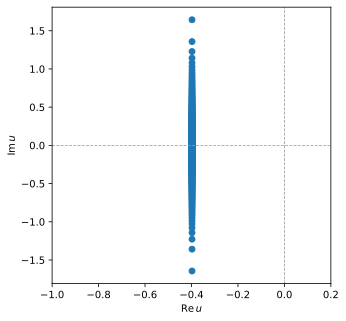

In [16]:
u = largeL_state.roots
ax = largeL_state.plot_roots()
ax.set_xlim([-1,0.2])

## Large-L root density

For the convention `u = -eta / 2 + 1j * alpha / 2`, the vertical coordinate of the root plot is

$$
y = \operatorname{Im} u = \frac{\alpha}{2}.
$$

If the thermodynamic root density is written as

$$
\rho_\alpha(\alpha) = \frac{1}{4\eta}\operatorname{sech}
\left(\frac{\pi\alpha}{2\eta}\right),
$$

then the density with respect to `y = alpha / 2` is

$$
\rho_y(y) = 2\rho_\alpha(2y)
= \frac{1}{2\eta}\operatorname{sech}
\left(\frac{\pi y}{\eta}\right).
$$

The left panel keeps the current `u`-root view; the right panel shares the same vertical axis and shows the horizontal density comparison.

Text(0.5, 0.98, 'XXZ root density, $L=1000$, $\\Delta=0.7$')

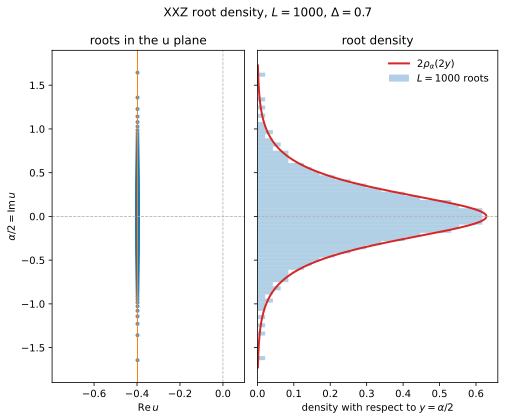

In [17]:
alpha = largeL_state.alphas
u = largeL_state.roots
y = alpha / 2.0
eta = largeL_state.eta

def sech(x):
    return 1.0 / np.cosh(x)

def rho_alpha(alpha):
    return sech(np.pi * alpha / (2.0 * eta)) / (4.0 * eta)

def rho_y(y):
    return 2.0 * rho_alpha(2.0 * y)

bins = 70
hist, edges = np.histogram(y, bins=bins, weights=np.ones_like(y) / L)
centers = 0.5 * (edges[:-1] + edges[1:])
widths = np.diff(edges)
density = hist / widths
grid = np.linspace(y.min() * 1.05, y.max() * 1.05, 600)

fig, (ax_u, ax_rho) = plt.subplots(
    1,
    2,
    figsize=(8, 6),
    sharey=True,
    gridspec_kw={"width_ratios": [1.0, 1.25], "wspace": 0.06},
)

ax_u.scatter(u.real, u.imag, s=10, alpha=0.65)
ax_u.axhline(0, color="0.7", linestyle="--", linewidth=0.8)
ax_u.axvline(0, color="0.7", linestyle="--", linewidth=0.8)
ax_u.axvline(-eta / 2.0, color="tab:orange", linewidth=1.0)
ax_u.set_xlabel(r"$\mathrm{Re}\,u$")
ax_u.set_ylabel(r"$\alpha/2 = \mathrm{Im}\,u$")
ax_u.set_title("roots in the u plane")
ax_u.set_xlim([-eta, 0.1])

ax_rho.barh(
    centers,
    density,
    height=widths,
    color="tab:blue",
    alpha=0.35,
    edgecolor="none",
    label=fr"$L={L}$ roots",
)
ax_rho.plot(rho_y(grid), grid, color="tab:red", linewidth=2.0, label=r"$2\rho_\alpha(2y)$")
ax_rho.axhline(0, color="0.7", linestyle="--", linewidth=0.8)
ax_rho.set_xlabel(r"density with respect to $y=\alpha/2$")
ax_rho.set_title("root density")
ax_rho.legend(frameon=False)

fig.suptitle(fr"XXZ root density, $L={L}$, $\Delta={Delta}$")

## Ground State in other sector

In [18]:
L = 16
qnums_custom = np.array([-3,-2,-1,0,1,2,3])

custom_state = solve_xxz_state(
    L,
    Delta,
    qnums=qnums_custom,
    raise_error=False,
)

custom_p = 2.0 * np.arctan(
    np.tanh(custom_state.alphas / 2.0) / np.tan(custom_state.eta / 2.0)
)
custom_p = (custom_p + np.pi) % (2.0 * np.pi) - np.pi
custom_P_total = (np.sum(custom_p) + np.pi) % (2.0 * np.pi) - np.pi

print(f"converged      : {custom_state.converged}")
print(f"residual norm  : {custom_state.residual_norm:.3e}")
print(f"qnums          : {custom_state.qnums}")
print(f"alpha          : {custom_state.alphas}")
print(f"p              : {custom_p}")
print(f"total momentum : {custom_P_total:.15e}")
print(f"energy         : {xxz_energy(custom_state):.15f}")
print(f"energy / L     : {xxz_energy_density(custom_state):.15f}")

converged      : True
residual norm  : 2.396e-14
qnums          : [-3. -2. -1.  0.  1.  2.  3.]
alpha          : [-0.79488648 -0.43978241 -0.20192688  0.          0.20192688  0.43978241  0.79488648]
p              : [-1.46479752 -0.95141844 -0.47019676  0.          0.47019676  0.95141844  1.46479752]
total momentum : 0.000000000000000e+00
energy         : -25.022466402599992
energy / L     : -1.563904150162500


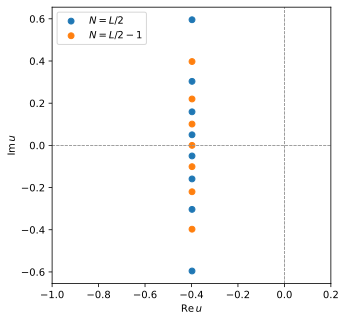

In [19]:
ax = state.plot_roots(label="$N=L/2$")
ax = custom_state.plot_roots(ax=ax, label="$N=L/2-1$")
ax.set_xlim([-1,0.2])
ax.legend()

In [20]:
oper = qt.generate.heisenberg_operator(L=16, j=(1,1,0.7), hz=0, cyclic=True)
basis = qt.generate.basis.spin_basis(L=16, Nup=9)
mat = oper.to_matrix(basis=basis, pauli=True, sparse=True)
eng = eigsh(mat, k=1, which='SA')[0][0]
print("ED energy:", eng)
print("BA energy:", xxz_energy(custom_state))

ED energy: -25.02246640260004
BA energy: -25.022466402599992


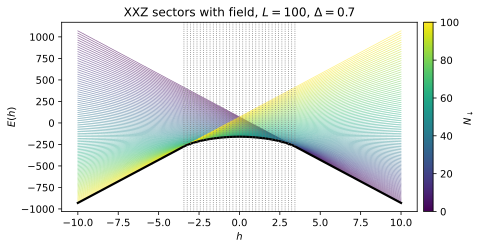

In [ ]:
from quante.generate.solvable.bethe_ansatz.xxz_z import plot_xxz_pbc_finite_energy_vs_h

h_values = np.linspace(-10.0, 10.0, 100)
plot_xxz_pbc_finite_energy_vs_h(L=100, delta=0.7, h_values=h_values);

100.0%   50 of 50   [########################################] 00:02<00:00, 17.34it/s


(-1.0, 0.2)

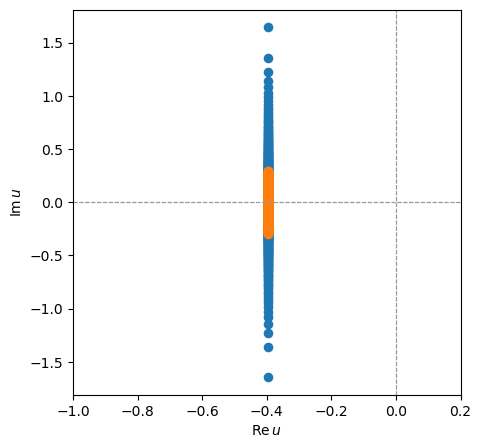

In [16]:
L = 1000
h = 2
minenergs = np.inf
for N in qt.basicfun.tqdm(range(300,350)):
    qnums_custom = np.arange((-N+1)/2,(N+1)/2, 1)
    custom_state = solve_xxz_state(
        L,
        Delta,
        qnums=qnums_custom,
        raise_error=False,
    )
    e = xxz_energy(custom_state) - 2*(L-2*N)
    if e < minenergs:
        minenergs = e
        minN = N
N = minN # 328
qnums_custom = np.arange((-N+1)/2,(N+1)/2, 1)
custom_state = solve_xxz_state(
    L,
    Delta,
    qnums=qnums_custom,
    raise_error=False,
)
e = xxz_energy(custom_state) - 2*(L-2*N)
ax = largeL_state.plot_roots(label="N=500")
custom_state.plot_roots(ax, label="N=328")
ax.set_xlim([-1,0.2])

Text(0.5, 0.98, 'XXZ root density, $L=1000$, $\\Delta=0.7$, h=2')

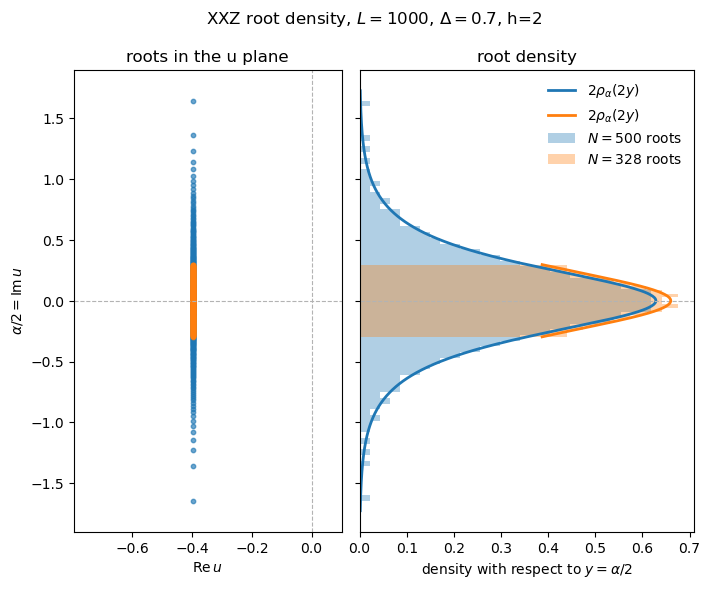

In [5]:
from quante.generate.solvable.bethe_ansatz.xxz_z import compute_ground_state_density

alpha = largeL_state.alphas
alpha2 = custom_state.alphas
u = largeL_state.roots
u2 = custom_state.roots
y = alpha / 2.0
y2 = alpha2 / 2.0
eta = largeL_state.eta

def sech(x):
    return 1.0 / np.cosh(x)

def rho_alpha(alpha):
    return sech(np.pi * alpha / (2.0 * eta)) / (4.0 * eta)

def rho_y(y):
    return 2.0 * rho_alpha(2.0 * y)

bins = 70
hist, edges = np.histogram(y, bins=bins, weights=np.ones_like(y) / L)
bins2 = 20
hist2, edges2 = np.histogram(y2, bins=bins2, weights=np.ones_like(y2) / L)
centers = 0.5 * (edges[:-1] + edges[1:])
centers2 = 0.5 * (edges2[:-1] + edges2[1:])
widths = np.diff(edges)
widths2 = np.diff(edges2)
density = hist / widths
density2 = hist2 / widths2
grid = np.linspace(y.min() * 1.05, y.max() * 1.05, 600)

fig, (ax_u, ax_rho) = plt.subplots(
    1,
    2,
    figsize=(8, 6),
    sharey=True,
    gridspec_kw={"width_ratios": [1.0, 1.25], "wspace": 0.06},
)

ax_u.scatter(u.real, u.imag, s=10, alpha=0.65)
ax_u.scatter(u2.real, u2.imag, s=10, alpha=0.65)
ax_u.axhline(0, color="0.7", linestyle="--", linewidth=0.8)
ax_u.axvline(0, color="0.7", linestyle="--", linewidth=0.8)
ax_u.set_xlabel(r"$\mathrm{Re}\,u$")
ax_u.set_ylabel(r"$\alpha/2 = \mathrm{Im}\,u$")
ax_u.set_title("roots in the u plane")
ax_u.set_xlim([-eta, 0.1])

ax_rho.barh(
    centers,
    density,
    height=widths,
    color="tab:blue",
    alpha=0.35,
    edgecolor="none",
    label=fr"$N=500$ roots",
)
ax_rho.barh(
    centers2,
    density2,
    height=widths2,
    color="tab:orange",
    alpha=0.35,
    edgecolor="none",
    label=fr"$N={N}$ roots",
)
ax_rho.plot(rho_y(grid), grid, color="tab:blue", linewidth=2.0, label=r"$2\rho_\alpha(2y)$")
ax_rho.axhline(0, color="0.7", linestyle="--", linewidth=0.8)
ax_rho.set_xlabel(r"density with respect to $y=\alpha/2$")
ax_rho.set_title("root density")

data = compute_ground_state_density(eta=eta, h=h)
x = data["alpha"]/2
y = data["rho"]*2
ax_rho.plot(y, x, color="tab:orange", linewidth=2.0, label=r"$2\rho_\alpha(2y)$")

ax_rho.legend(frameon=False)
fig.suptitle(fr"XXZ root density, $L={L}$, $\Delta={Delta}$, h=2")

In [6]:
data.filling_density()

0.3277326081917401

dressed energy

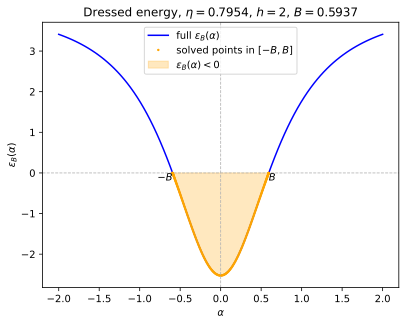

In [53]:
qt.basicfun.plt_style_use('default')
data = compute_ground_state_density(eta=eta, h=2.0)
alphas = np.linspace(-2,2,100)
data.plot_dressed_energy(alphas)